Given appropriately loaded data, we can stack the events and look at them

In [1]:
import numpy as np
import obspy
import lfeanalysis
import matplotlib.pyplot as plt
from importlib import reload
reload(lfeanalysis)

<module 'lfeanalysis' from '/home/petoskey_data/Dropbox/SMALLSYNC/PYFILES/LFEFocMech/lfeanalysis.py'>

### 1. Initialize data and detections

First, we need to load in all the data and the detection times

In [2]:
# as before, we need to initialize an analysis object
lf=lfeanalysis.lfanalyse(fnum=156)

In [3]:
# read detection info and templates                                                             
lf.read_detection_info()
lf.pick_templates()

# read, normalize, and filter the data                                                          
lf.read_data()
lf.normalize_data(single_norm=False)
lf.filter_data(flm=[1,10])

# compute LFE rates                                                                             
lf.identify_sse_times()
lf.compute_lfe_rates(bin_duration=5*3600)

# bin the LFEs into groups by time in the SSE                                                   
lf.select_start_times()
lf.group_events_bytime()


In [4]:
# alternatively, we could run all this by 
lf=lfeanalysis.lfanalyse(fnum=156)
lf.load_prep_data(flm=[1,10],single_norm=False)

Reading data
Normalizing data
Filtering data


### 2. Stack


In [5]:
# stack for each group
lf.stack_by_group()

In [6]:
# we now have several stacks
# lf.totstk includes *all* the LFEs
print(lf.totstk)

# it's an obspy stream with a trace for each station/channel
print('\nThe fourth trace:\n',lf.totstk[3])

27 Trace(s) in Stream:

.B926..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples
...
(25 other traces)
...
.YOUB..Z | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]

The fourth trace:
 .KHVB..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples


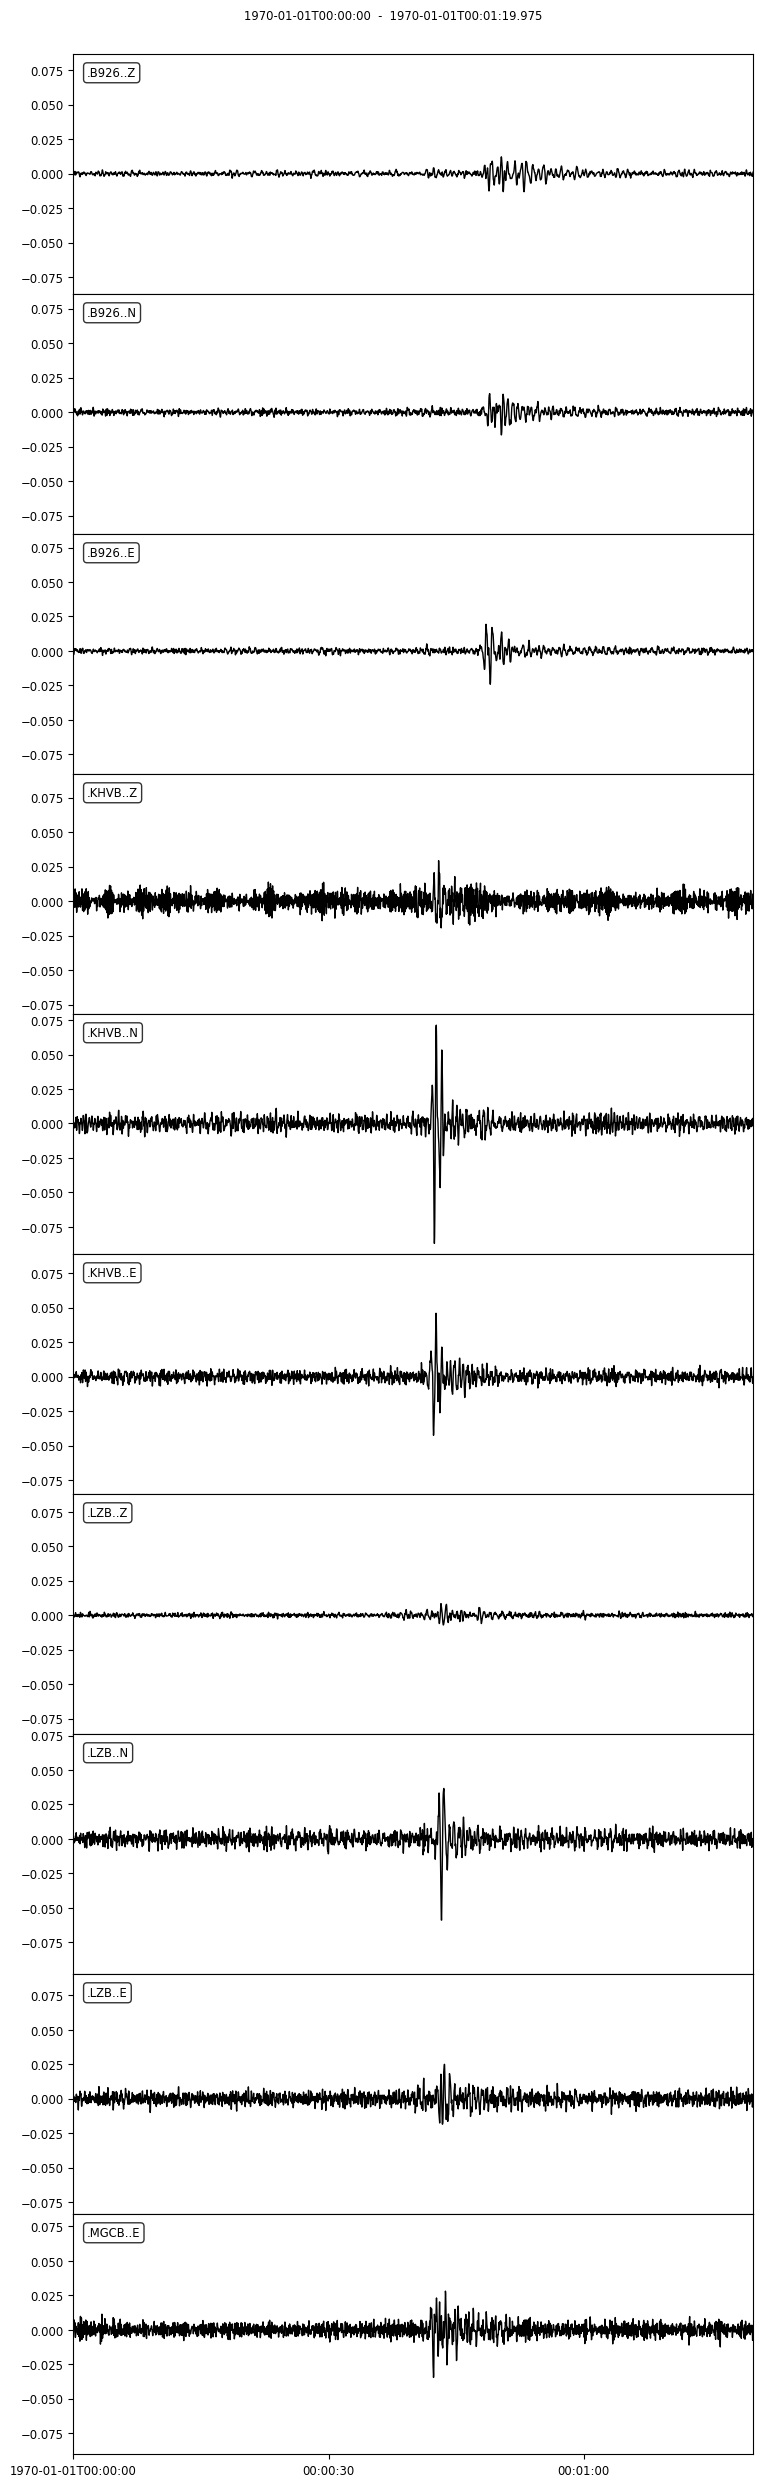

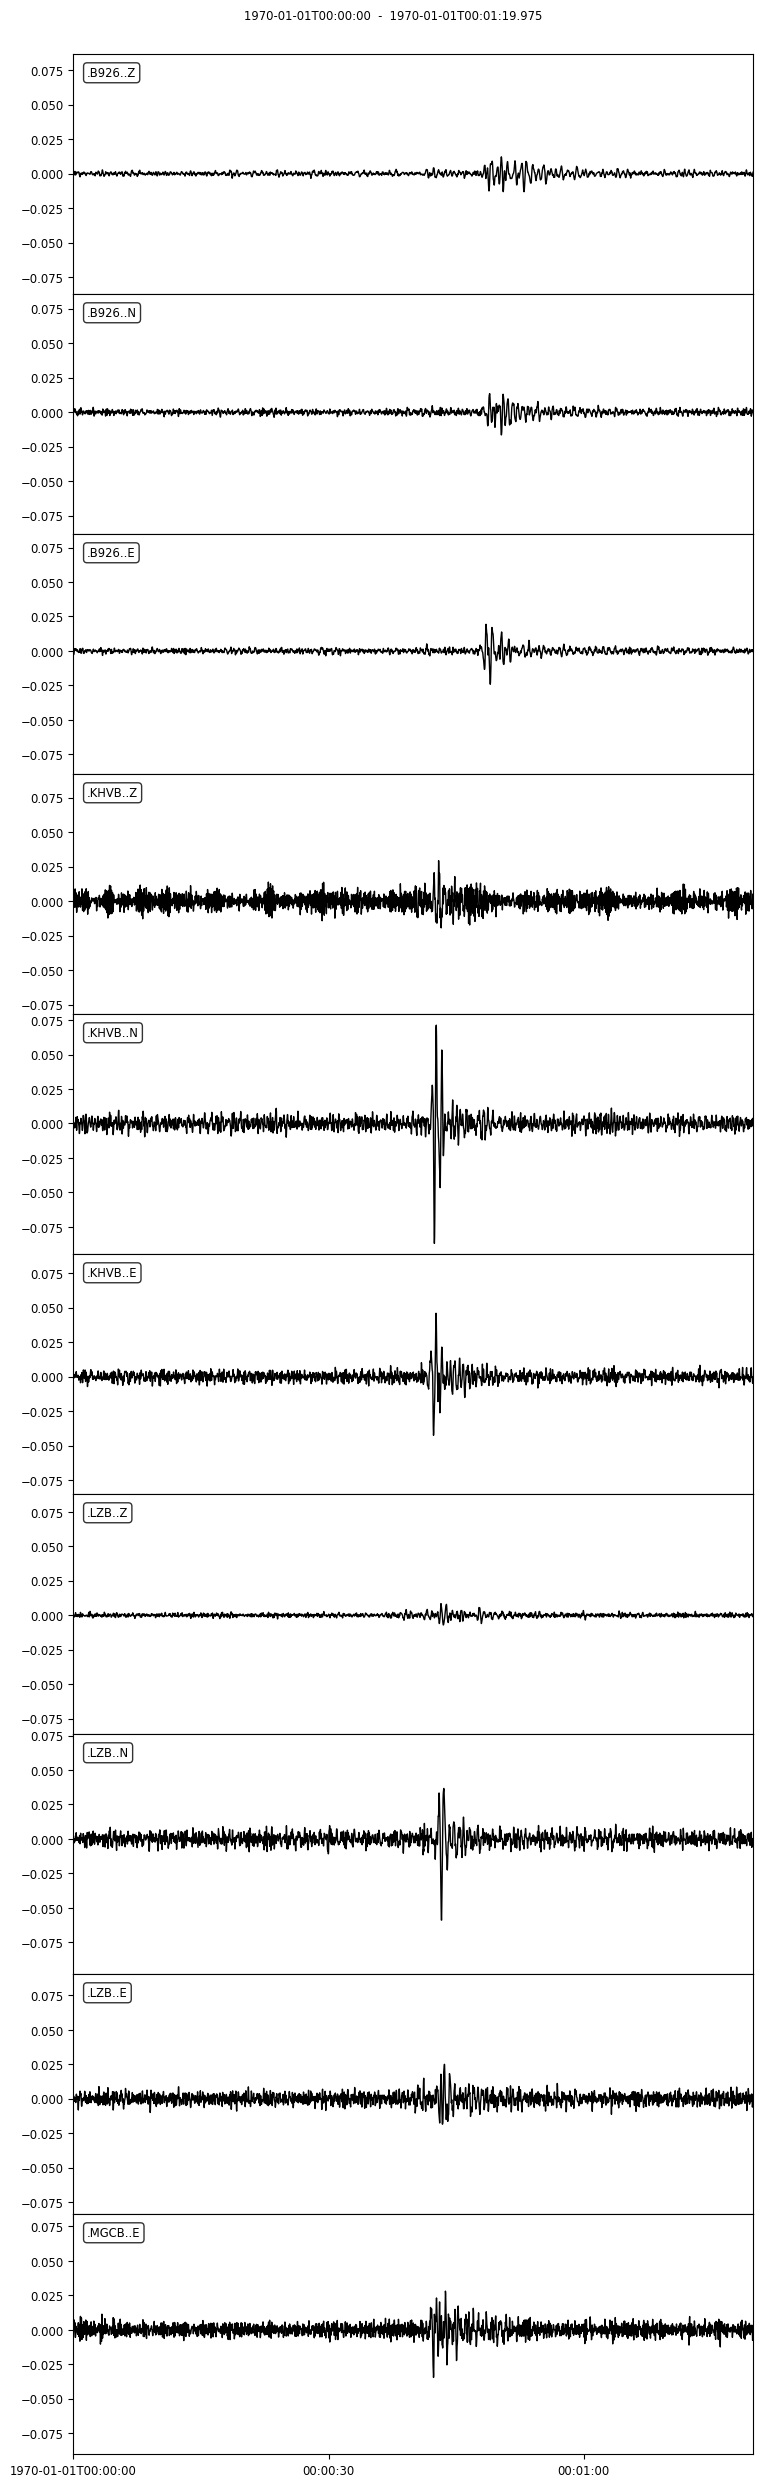

In [7]:
# plot the first 10 traces in the stack
lf.totstk[0:10].plot()

In [8]:
# note that after stacking we've changed the channel naming conventions
# so now 'E' is for eastward velocities, 'N' is for northward velocities, 
# and 'Z' is for upward velocities

print('The first trace\'s channel is {:s}'.format(lf.totstk[0].stats.channel))

The first trace's channel is E


In [9]:
# there is also a stack for each group in a dictionary lf.grpstk
print(lf.grpstk)

print('\nThe stack for the early group:\n',lf.grpstk['early'])

{'early': <obspy.core.stream.Stream object at 0x7fe5cd461c90>, 'late': <obspy.core.stream.Stream object at 0x7fe5cd461ba0>}

The stack for the early group:
 27 Trace(s) in Stream:

.B926..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples
...
(25 other traces)
...
.YOUB..Z | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples

[Use "print(Stream.__str__(extended=True))" to print all Traces]


### 3. Pick the arrival times on the stack

We'll also want to know where in the traces the LFEs are recorded.

The LFE signal in the first trace starts 47.8s after the start time

All the picks:  {'B926': 47.75, 'KHVB': 41.625, 'LZB': 42.45, 'MGCB': 41.425000000000004, 'NLLB': 54.800000000000004, 'PGC': 42.125, 'SHDB': 43.775000000000006, 'SHVB': 42.050000000000004, 'YOUB': 51.1}


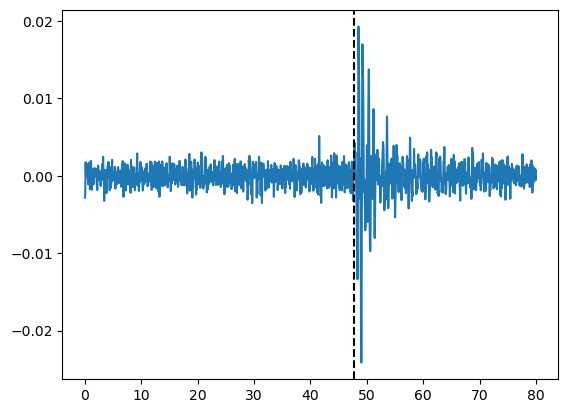

In [10]:
reload(lfeanalysis)
lf=lfeanalysis.lfanalyse(lfi=lf)

# pick the max snr times 
# on the stack of all events, not per group
lf.pick_stacks(wlen=[0,4],minsnr=10)

# this saves the start time of the window with highest snr in tr.stats.t0
tr=lf.totstk[0]
print('The LFE signal in the first trace starts {:0.1f}s after the start time'.format(tr.stats.t0))

plt.plot(tr.times(),tr.data);
plt.axvline(tr.stats.t0,color='k',linestyle='--');

# the pick times are also noted in lf.stack_picks
# one pick per station, not per channel
print('\nAll the picks: ',lf.stackpicks)

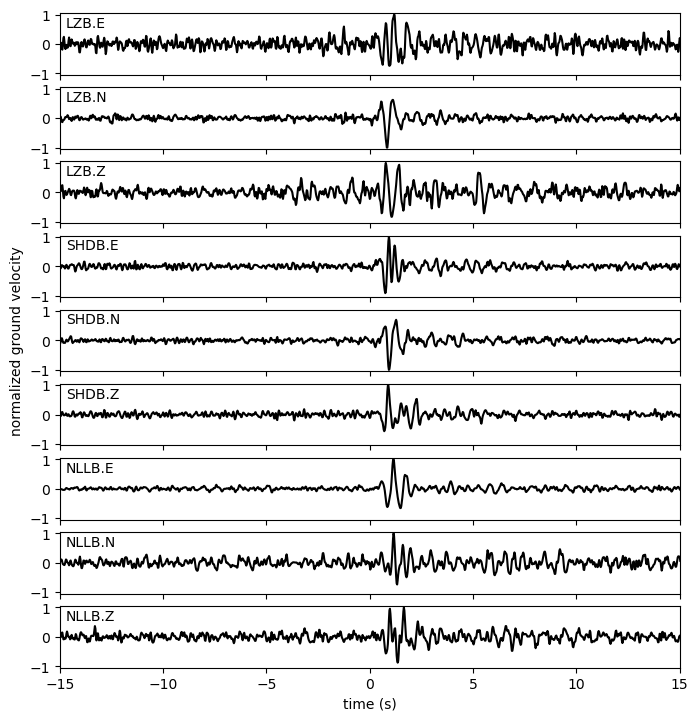

In [11]:
# now we can plot the stacks
# plot the average of all events:
lf.plot_stacks('all')


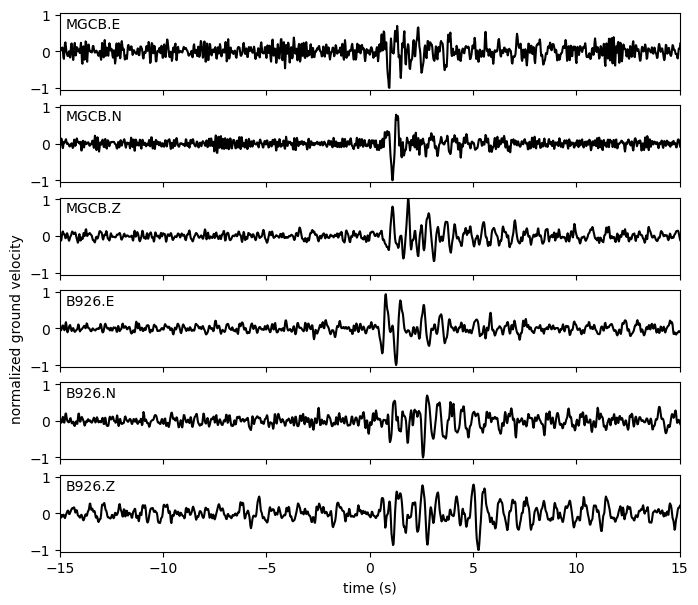

In [12]:
# or maybe just plot the events in the early group at stations 'MGCB' and 'B926'
lf.plot_stacks(stype='early',stn=['MGCB','B926'])

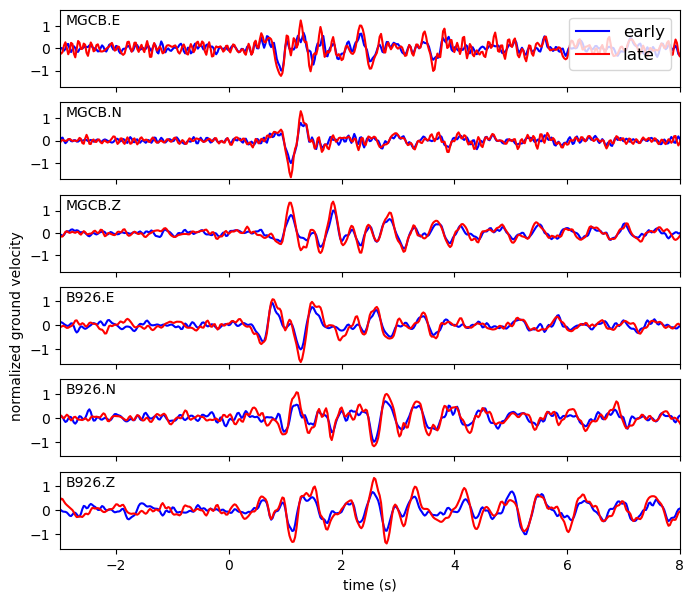

In [13]:
# might also want to plot the stacks from the late events along with the early ones
lf.plot_stacks(stype='early',stn=['MGCB','B926'],color='blue',morestacks=['late'],tlm=[-3,8])

### 4. Note the bootstrapped stacks

When we stacked the data using lf.stack_by_group, we also created a few more stacks by selecting random subsets of the data.  Here we're trying to see how much the results could vary if instead of using all the LFEs, we use a random subset.

So lf.totstk includes stacks of all events, but lf.totstkb includes 10 different stacks, created by stacking 10 different subsets of the data. 

In [14]:
print(lf.totstkb)

{'B926.E': array([[-4.68225361e-03, -3.60261826e-03, -2.03084441e-03, ...,
        -3.54707874e-03, -2.49530530e-03, -3.65950343e-03],
       [-4.72146561e-03, -2.02216556e-03, -1.28917695e-03, ...,
        -2.61093718e-03, -2.05923460e-03, -3.70829086e-03],
       [-4.76501829e-03, -1.60539231e-03, -1.71034804e-03, ...,
        -1.61412159e-03, -2.76550743e-03, -3.17362742e-03],
       ...,
       [-1.75660905e-03,  1.48288881e-04,  1.93871609e-03, ...,
        -7.61737338e-04, -3.49325886e-04, -1.08187579e-03],
       [-1.78365821e-03,  1.11139270e-03,  2.77828367e-03, ...,
        -5.79711020e-04, -7.42958562e-04, -1.26064768e-03],
       [-8.91114580e-04,  1.29697226e-03,  2.84417100e-03, ...,
        -3.01061863e-05, -3.39732875e-04,  4.29294360e-05]]), 'B926.N': array([[ 0.00023399,  0.00099548,  0.00150884, ..., -0.00040209,
        -0.00069991,  0.00091321],
       [ 0.00099021,  0.00119251,  0.00223779, ..., -0.00084794,
        -0.00033918,  0.00071143],
       [ 0.00213914, 

.B926..E | 1970-01-01T00:00:00.000000Z - 1970-01-01T00:01:19.975000Z | 40.0 Hz, 3200 samples

 (3200, 10)


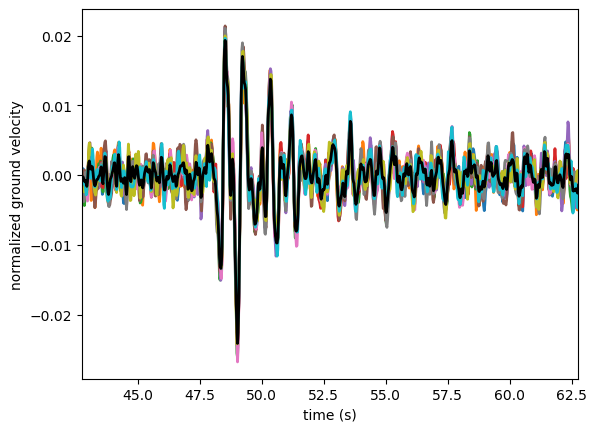

In [15]:
# let's look at the bootstrapped stacks for station B926, station E

# the trace with all the events
tr=lf.totstk.select(channel='E',station='B926')[0]
print(tr)

# the bootstrapped stacks
stkb=lf.totstkb['B926.E']
print('\n',stkb.shape)

plt.plot(tr.times(),stkb,linewidth=2,label='bootstrapped');
plt.plot(tr.times(),tr.data,color='k',linewidth=2,label='full stack');
plt.xlim(np.array([-5,15])+tr.stats.t0);
plt.xlabel('time (s)');
plt.ylabel('normalized ground velocity');

In [16]:
# likewise we have stacks for the groups
print(lf.grpstkb)

{'early': {'B926.E': array([[-1.25689278e-03, -2.08419041e-03,  4.78429433e-03, ...,
        -3.57758563e-03,  3.43681715e-04, -1.82661439e-03],
       [-1.65953789e-03, -1.94752914e-03,  4.02934063e-03, ...,
        -3.83627088e-03,  1.29634821e-04, -2.89544842e-03],
       [-3.94102641e-03, -3.06512051e-03,  3.38046955e-04, ...,
        -3.74071321e-03, -2.43625919e-03, -3.13833783e-03],
       ...,
       [-1.44058006e-03,  7.09952585e-04,  1.11947626e-03, ...,
         1.76829753e-03,  2.07211939e-05, -2.70438193e-03],
       [-2.58615038e-03,  2.40091749e-03,  4.37994291e-04, ...,
        -1.13295758e-04, -1.67415911e-03, -3.75138218e-03],
       [-3.28902592e-03,  2.03978104e-03, -5.04591969e-04, ...,
        -1.36705558e-03, -1.83293490e-03, -3.01594383e-03]]), 'B926.N': array([[ 3.27100139e-03,  1.02498229e-03,  3.90230331e-03, ...,
         1.76465315e-03,  6.96609665e-04,  3.28743309e-03],
       [ 5.07624212e-03,  2.12449214e-03,  4.16220777e-03, ...,
         5.85863989e-04

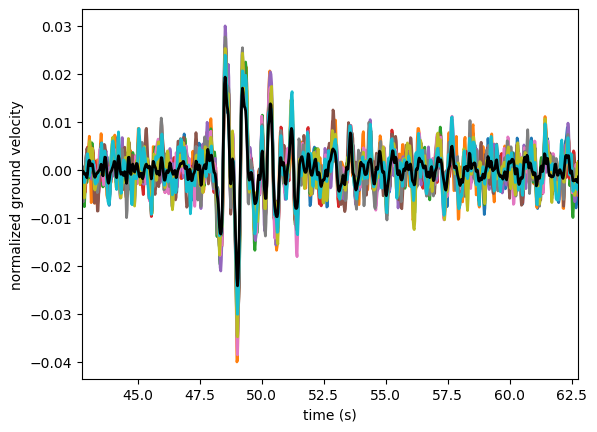

In [17]:
# here's the bootstrapped stacks for B926.E for the late group
stkb_late=lf.grpstkb['late']['B926.E']

plt.plot(tr.times(),stkb_late,linewidth=2,label='bootstrapped late');
plt.plot(tr.times(),tr.data,color='k',linewidth=2,label='full stack');
plt.xlim(np.array([-5,15])+tr.stats.t0);
plt.xlabel('time (s)');
plt.ylabel('normalized ground velocity');